In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stillib_plotting import despine, save, use_style

from mscthesis.config import ProjectConfig
from mscthesis.core.io import load_dataframe
from mscthesis.paths import ProjectPaths

config = ProjectConfig()
paths = ProjectPaths(config.behavior.storage_root) 


CMAP = "inferno"
facecolor = "#C7B7B7"
fs = 14
use_style() 




# EXPANSION

In [60]:
df_ = load_dataframe("/home/andreasstillits/coding/MasterThesis/.final/pipes/experiments/results.csv")
df_.head()

,Unnamed: 0,index,plug_aspect,stomatal_aspect,resistance_mean,resistance_std
0,0,0,0.100,0.025,1.195170,1.936843e-07
1,1,1,0.100,0.050,1.050779,4.912713e-07
2,2,2,0.100,0.075,1.009431,4.028979e-07
3,4,4,0.125,0.025,1.338533,1.791014e-07
4,5,5,0.125,0.050,1.108132,1.097599e-06


## Heatmap

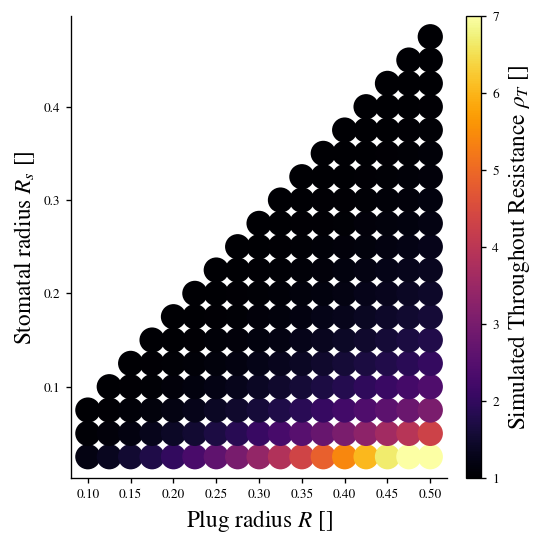

In [93]:


fig, ax = plt.subplots(figsize=(5, 5))
sc = ax.scatter(df_["plug_aspect"], df_["stomatal_aspect"], c=df_["resistance_mean"], cmap=CMAP, vmin=1, vmax=7, marker="o", s=200)
cbar = fig.colorbar(sc, pad=0.04, aspect=30)
cbar.set_label(r"Simulated Throughout Resistance $\rho_T$ []", fontsize=fs)
ax.set_xlabel(r"Plug radius $R$ []", fontsize=fs)
ax.set_ylabel(r"Stomatal radius $R_s$ []", fontsize=fs)
despine(ax)

save(fig, "./saved/expansion_heatmap.pdf")
plt.show()


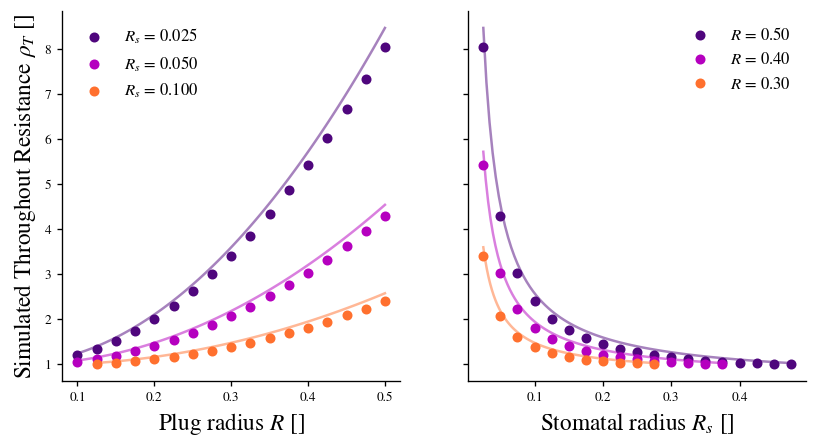

In [123]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=True)

colors = ["#4F067D", "#B500BF", "#FF702E"]

for stomatal, color in zip([0.025, 0.05, 0.10], colors):
    mask = df_["stomatal_aspect"] == stomatal
    ax1.scatter(df_["plug_aspect"][mask], df_["resistance_mean"][mask], c=color, label=r"$R_s$"+f" = {stomatal:.3f}", marker="o", s=25)
    rs = np.linspace(df_["plug_aspect"][mask].min(), df_["plug_aspect"][mask].max(), 100)
    ax1.plot(rs, 1 + np.pi/4 * rs * (rs / stomatal - 1), c=color, alpha=0.5)

ax1.set_xlabel(r"Plug radius $R$ []", fontsize=fs)
ax1.set_ylabel(r"Simulated Throughout Resistance $\rho_T$ []", fontsize=fs)
despine(ax1)
ax1.legend(fontsize=fs-4)

for plug, color in zip([0.50, 0.40, 0.30], colors):
    mask = np.isclose(df_["plug_aspect"], plug)
    ax2.scatter(df_["stomatal_aspect"][mask], df_["resistance_mean"][mask], c=color, label=r"$R$"+f" = {plug:.2f}", marker="o", s=25)
    ps = np.linspace(df_["stomatal_aspect"][mask].min(), df_["stomatal_aspect"][mask].max(), 100)
    ax2.plot(ps, 1 + np.pi/4 * plug * (plug / ps - 1), c=color, alpha=0.5)

ax2.set_xlabel(r"Stomatal radius $R_s$ []", fontsize=fs)
# ax2.set_ylabel(r"Simulated Throughout Resistance $\rho_T$ []", fontsize=fs)
despine(ax2)
ax2.legend(fontsize=fs-4)

plt.show()

# DIFFUSION

In [62]:
df = load_dataframe(paths.diffusion_index.require())
df.head()

,Unnamed: 0,type,sample_id,specifier,plug_aspect,stomatal_aspect,r_empty_calc,tomas,earles,surface_centroid,r_porous_top,r_porous_mean,r_dirichlet,r_neumann,r_empty,r_porous_top_0,r_porous_mean_0
0,0,contrast,00331,0,0.331512,0.332444,1.000000,0.872398,0.740729,0.424617,1.664934,0.885786,0.111733,0.625501,1.000140,1.664934,0.885786
1,1,contrast,00331,1,0.331512,0.019773,5.105051,0.873261,0.741462,0.424617,5.567980,4.785575,4.205256,4.502564,4.814744,1.664934,0.885786
2,2,contrast,00331,2,0.331512,0.029854,3.630883,0.873261,0.741462,0.424617,4.197726,3.415253,2.661757,3.142461,3.448709,1.664934,0.885786
3,3,contrast,00331,3,0.331512,0.039886,2.903679,0.873261,0.741462,0.424617,3.499637,2.717089,1.893613,2.444288,2.755095,1.664934,0.885786
4,4,contrast,00331,4,0.331512,0.049907,2.469169,0.873261,0.741462,0.424617,3.075878,2.293454,1.424524,2.022881,2.336691,1.664934,0.885786


## Expansion Contribution

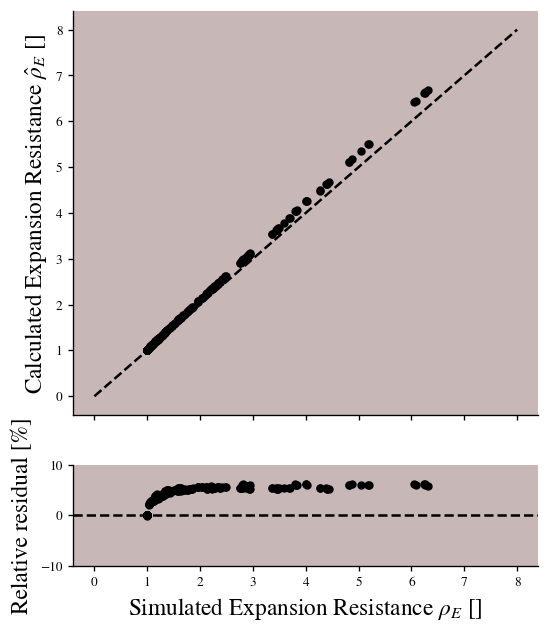

In [63]:
empty = df["r_empty"] 
empty_calc = df["r_empty_calc"]
residual = 100 * (empty_calc - empty) / empty

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), sharex=True, gridspec_kw={'height_ratios': [4, 1]})
sc = ax1.scatter(empty, empty_calc, color="#000000")
ax1.plot([0, 8], [0, 8], 'k--', zorder=0)
despine(ax1)
ax1.set_facecolor(facecolor)
# ax1.set_xlabel(r"Simulated Resistance $\rho$ []", fontsize=fs)
ax1.set_ylabel(r"Calculated Expansion Resistance $\hat{\rho}_{E}$ []", fontsize=fs)


ax2.scatter(empty, residual, color="k", label="Relative residual")
ax2.axhline(0, color="k", linestyle="--", zorder=0)
despine(ax2)
ax2.set_facecolor(facecolor)
ax2.set_xlabel(r"Simulated Expansion Resistance $\rho_E$ []", fontsize=fs)
ax2.set_ylabel("Relative residual [%]", fontsize=fs)
ax2.set_ylim(-10, 10)

save(fig, "./saved/expansion_comparison.pdf")

plt.show()

## Serial Decomposition

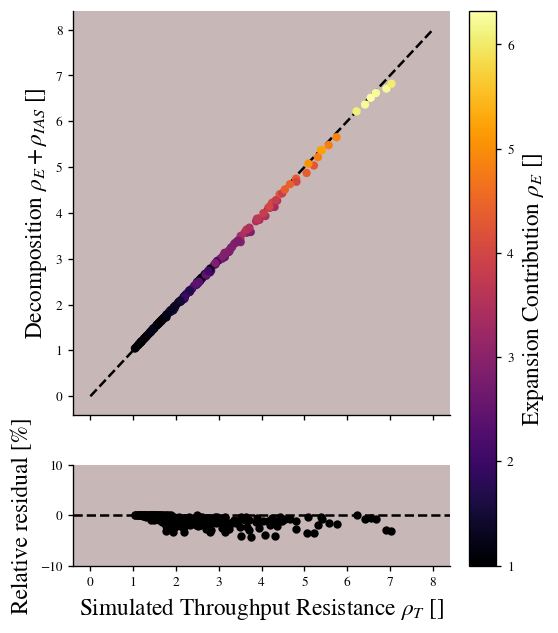

In [64]:
simulated = df["r_porous_top"]
empty = df["r_empty"]
full = df["r_porous_top_0"]
summed = (empty - 1) + full 
residual = 100 * (summed - simulated)/simulated

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 6), sharex=True, gridspec_kw={'height_ratios': [4, 1]})
sc = ax1.scatter(simulated, summed, c=empty, cmap=CMAP)
cbar = fig.colorbar(sc, ax=[ax1, ax2], pad=0.04)
cbar.set_label(r"Expansion Contribution $\rho_E$ []", fontsize=fs)
ax1.plot([0, 8], [0, 8], 'k--', zorder=0)
despine(ax1)
ax1.set_facecolor(facecolor)
# ax1.set_xlabel(r"Simulated Resistance $\rho$ []", fontsize=fs)
ax1.set_ylabel(r"Decomposition $\rho_E + \rho_{IAS}$ []", fontsize=fs)


ax2.scatter(simulated, residual, color="k", label="Relative residual")
ax2.axhline(0, color="k", linestyle="--", zorder=0)
despine(ax2)
ax2.set_facecolor(facecolor)
ax2.set_xlabel(r"Simulated Throughput Resistance $\rho_T$ []", fontsize=fs)
ax2.set_ylabel("Relative residual [%]", fontsize=fs)
ax2.set_ylim(-10, 10)

save(fig, "./saved/decomposition.pdf")

plt.show()


## IAS CONTRIBUTION

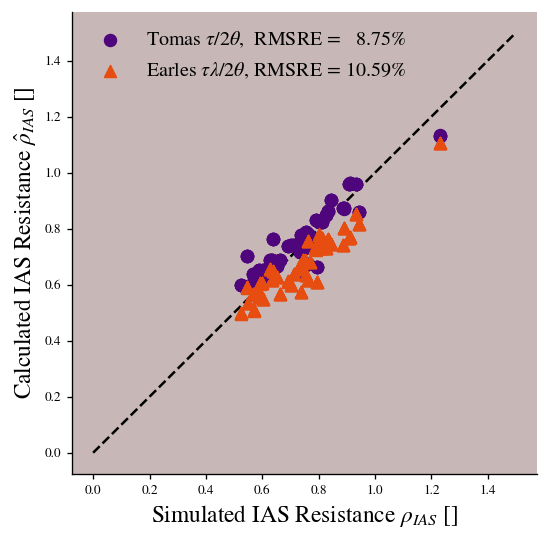

Mean relative residual for Tomàs: 8.75%
Mean relative residual for Earles: 10.59%


In [65]:
simulated = df["r_porous_mean_0"]
tomas = df["tomas"]
earles = df["earles"]

tomas_res = np.sqrt((((tomas - simulated) / simulated * 100)**2).mean())
earles_res = np.sqrt((((earles - simulated) / simulated * 100)**2).mean())

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(simulated, tomas, color="#4F067D", marker="o", s=50, label=r"Tomas $\tau/2 \theta$"+f",  RMSRE =   {tomas_res:.2f}%")
ax.scatter(simulated, earles, color="#E74D11", marker="^", s=50, label=r"Earles $\tau\lambda/2 \theta$"+f", RMSRE = {earles_res:.2f}%")
ax.plot([0, 1.5], [0, 1.5], 'k--', zorder=0)
despine(ax)
ax.set_facecolor(facecolor)
ax.set_xlabel(r"Simulated IAS Resistance $\rho_{IAS}$ []", fontsize=fs)
ax.set_ylabel(r"Calculated IAS Resistance $\hat{\rho}_{IAS}$ []", fontsize=fs)
ax.legend(fontsize=fs-2)

save(fig, "./saved/ias_formulas.pdf")

plt.show()

print(f"Mean relative residual for Tomàs: {tomas_res:.2f}%"
)
print(f"Mean relative residual for Earles: {earles_res:.2f}%")

## Neumann

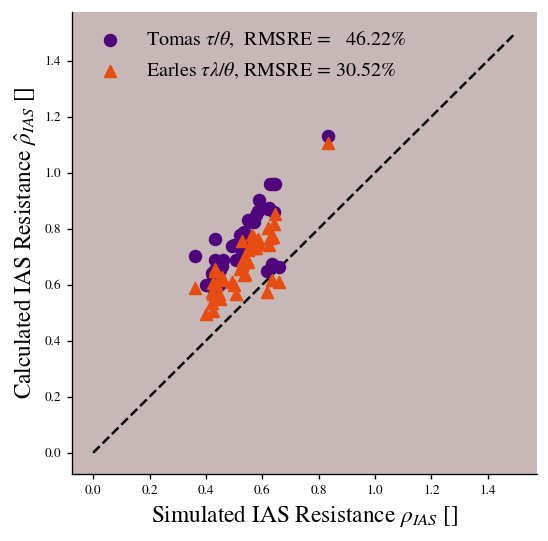

Mean relative residual for Tomàs: 46.22%
Mean relative residual for Earles: 30.52%


In [66]:
mask = df["specifier"] == 0

simulated = df["r_neumann"][mask]
tomas = df["tomas"][mask]
earles = df["earles"][mask]

tomas_res = np.sqrt((((tomas - simulated) / simulated * 100)**2).mean())
earles_res = np.sqrt((((earles - simulated) / simulated * 100)**2).mean())

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(simulated, tomas, color="#4F067D", marker="o", s=50, label=r"Tomas $\tau/\theta$"+f",  RMSRE =   {tomas_res:.2f}%")
ax.scatter(simulated, earles, color="#E74D11", marker="^", s=50, label=r"Earles $\tau\lambda/\theta$"+f", RMSRE = {earles_res:.2f}%")
ax.plot([0, 1.5], [0, 1.5], 'k--', zorder=0)
despine(ax)
ax.set_facecolor(facecolor)
ax.set_xlabel(r"Simulated IAS Resistance $\rho_{IAS}$ []", fontsize=fs)
ax.set_ylabel(r"Calculated IAS Resistance $\hat{\rho}_{IAS}$ []", fontsize=fs)
ax.legend(fontsize=fs-2)


plt.show()

print(f"Mean relative residual for Tomàs: {tomas_res:.2f}%"
)
print(f"Mean relative residual for Earles: {earles_res:.2f}%")

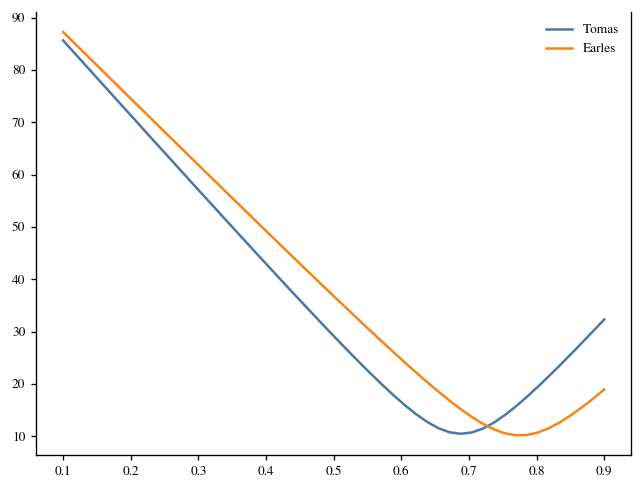

In [67]:
xs = np.linspace(0.1, 0.9, 50)

def func_tomas(x) -> float:
    simulated = df["r_neumann"][mask]
    tomas = df["tomas"][mask] * x
    return np.sqrt((((tomas - simulated) / simulated * 100)**2).mean())

def func_earles(x) -> float:
    simulated = df["r_neumann"][mask]
    earles = df["earles"][mask] * x
    return np.sqrt((((earles - simulated) / simulated * 100)**2).mean())

ys_tomas = [func_tomas(x) for x in xs]
ys_earles = [func_earles(x) for x in xs]
plt.plot(xs, ys_tomas, label="Tomas")
plt.plot(xs, ys_earles, label="Earles")
plt.legend()